## Introduction

This notebook explores the standardization of restaurant menu items into a controlled taxonomy.
- Entree
- Side
- Drink
- Dessert
- Add-On

Restaurant-provided categories are inconsistent and often contain brand-specific naming conventions. This pipeline uses rule-based classification and calorie thresholds to normalize the categories. Accurate categorization is critical to EateryAI's recommendation engine because certain contraints will intentionally exclude specific categories.

In [73]:
# !pip install matplotlib

In [ ]:
import json
import copy
import matplotlib.pyplot as plt

with open("../restaurants.menu_item_variations.json", "r") as f:
    data = json.load(f)

## Defined Categories
Standardized category mapped to a set of common/restaurant specific categories identified from items that were not successfully recategorized.

### Categoization Steps

1) Restaurant Override - Some restaurants only include items of a single category like:
- Cold Stone Creamery (all items categorized as desserts)
- Cinnabon (all baked goods categorized as desserts)

2) Keyword Matching - This step checks both the original category name and the menu item name with the standardized categories mapped to a set of known keywords:
- Common (burger, pasta, burrito)
- Restaurant Specific (zalad, blizzard, tastee-freez, crave coolers, moolattes)

3) Calories are used to resolve ambiguous cases. This helps differentiate 1) small snack vs full meals and 2) protein add-ons vs full protein entress:
- Side or Add-On items &ge; 450 calories &rarr; upgrade to Entree
- Items &le; 110 calories &rarr; classified as Add-On
- Items &ge; 900 calories &rarr; classified as Entree

In [4]:
CATEGORIES = {
    "Entree": {"entree", "breakfast", "lunch", "dinner", "soup", "salad", "burrito", "taco", "kabob", "fish", "meal",
                "sandwich", "steak", "bagel", "bowl", "plate", "wing", "tender", "seafood", "pizza", "pancake", "sirloin", "burger",
                "dog", "pasta", "quesadilla", "main", "stromboli", "calzone", "rice", "noodle", "build", "sub", "taquito", "slider",
                "pita", "zalad", "loco", "wrap", "panini", "focaccia", "ciabatta", "rib", "shepard", "poke", "meatloaf", "halibut", 
                # shepard added to capture pie as entree vs dessert
                "bisque", "roll", "combo", "combination", "enchilada", "fajita", "tamales", "feast", "platter", "omelet", "waffle", 
                "chili", "melt", "flatizza", "nacho", "specialties", "dim sum", "stack", "hoagie", "spud", "quiche", "salmon", "liver", 
                "gizzard", "boat", "stir-fry", "grilled", "piccata", "crab", "lobster", "chalupa", "filet",  "menu hacks", "casserole", 
                "bruschett"},
    "Side": {"side", "starters", "chips", "snack", "munch", "kid", "children", "appetizer", "edamame", 
             "hummus", "fries", "popper", "bite", "fruit", "mac & cheese", "flatbread", "tornado", "dip", "potato", "pretzel", "croissant", 
             "toast", "shareable", "pups", "hash", "nudies"},
    "Drink": {"drink", "beverage", "coffee", "water", "beer", "slush", "smoothie", "cocktail", "wine", "refresher", "tea", "blend", "cappuccino", 
              "frappe", "lemonade", "mimosa", "margarita", "soda", "espresso", "juice", "limeade", "cervezas", "shots", "bloody mary"},
    "Dessert": {"dessert", "ice cream", "custard", "shake", "cake", "yogurt", "donut", "doughnut", "float", "blizzard", "blast", "chocolate", 
                "sundae", "freezee", "cooler", "brownie", "frosty", "caramel", "pie", "cookie", "pastries", "muffin", "bakery", "cone", "puddin", 
                "icee", "danish", "mixer", "baked goods", "signature creations", "moolattes", "coolattas", "lemon ice", "concrete", 'souffle', 
                "fritter", "bundt", "cobbler", "pastry", "bars", "treat", "banana", "novelties", "creams", "julius"},
    "Add-On": {"topping", "condiment", "add", "add-on", "add on", "addon", "mix-in", "ingredient", "dressing", "sauce", "proteins", "beans",
               "chicken", "pork", "beef", "option", "avocado", "flavor", "cheese", "aioli", "bacon", "meat", "vegetable", "supplement", 
               "family", "bread", "protein", "base", "sausage", "components", " for ", " on ", "extra", "boost", "turkey", "crust", "pastrami", 
               "shrimp", "tempura", "pepperoni", "hot bar", "oil", "pesto", "guac", "egg", "vinaigrette", "spinach"}
               # check calories to determine if items like "chicken" are entree or side/add-on
}

SDAO_UPGRAGE_THRESHOLD = 450
LOW_CAL_ADDON_THRESHOLD = 110
HIGH_CAL_ENTREE_THRESHOLD = 900

FORCE_DESSERT_RESTAURANTS = {"Cold Stone Creamery", "Cinnabon"}

In [5]:

def restaurant_category_override(item):
    if item["restaurant_name"] in FORCE_DESSERT_RESTAURANTS:
        item["category"] = "Dessert"
        return True
    return False

In [40]:
def categorize_item(item):
    # check both category and item name
    cat = item["category"].lower()
    name = item["menu_item_name"].lower()
    cals = item["nutrition_info"]["calories"]

    if restaurant_category_override(item):
        item["recategorize_reason"] = "override"
        return "Dessert"
    
    for standardized_cat, keywords in CATEGORIES.items():
        for word in keywords:
            if word in cat or word in name:
                # classify itemes that are more than 450 cals as entrees
                if standardized_cat in {"Side", "Add-On"} and cals >= SDAO_UPGRAGE_THRESHOLD:
                    item["recategorize_reason"] = "calorie_upgrade"
                    return "Entree"
                item["recategorize_reason"] = "category_match"
                return standardized_cat
            
    # usually items under 110 calories are a side/add-on
    if cals <= LOW_CAL_ADDON_THRESHOLD:
        item["recategorize_reason"] = "calorie_threshold"
        return "Add-On"
    elif cals >= HIGH_CAL_ENTREE_THRESHOLD:
        item["recategorize_reason"] = "calorie_threshold"
        return "Entree"
    return None

In [41]:
good_cat = []
bad_cat = []

# dup data
items = copy.deepcopy(data)


for item in items:
    new_cat = categorize_item(item)
    if new_cat:
        item["category"] = new_cat
        good_cat.append(item)
    else:
        bad_cat.append(item)

In [20]:
# print number of successful categorizations vs unknown
print(f"Successful: {len(good_cat)}")
print(f"Unknown: {len(bad_cat)}")

Successful: 35126
Unknown: 0


## File Output
corrected_category.json
- total count of successfully recategorized items
- all normalized items with updated categories

unknown_category.json
- used to identify keywords to add to defined category keywords
- could be used in the future to store items for manual review (some confidence score)

In [42]:
# dump successful/unknown categorizations
with open("corrected_category.json", "w") as correct:
    json.dump(good_cat, correct, indent=4)

with open("unknown_category.json", "w") as unknown:
    json.dump(bad_cat, unknown, indent=4)

## Edge Cases
- "add" being a keyword for Add-Ons could misclassify some entrees like "haddock" if the item is less than 450 calories

## Visualization and Exploration

In [22]:
# Unique categories before vs 5 standardized categorized now
unique_cats = {d["category"] for d in data}
print(f"Unique categories before: {len(unique_cats)}")

Unique categories before: 925


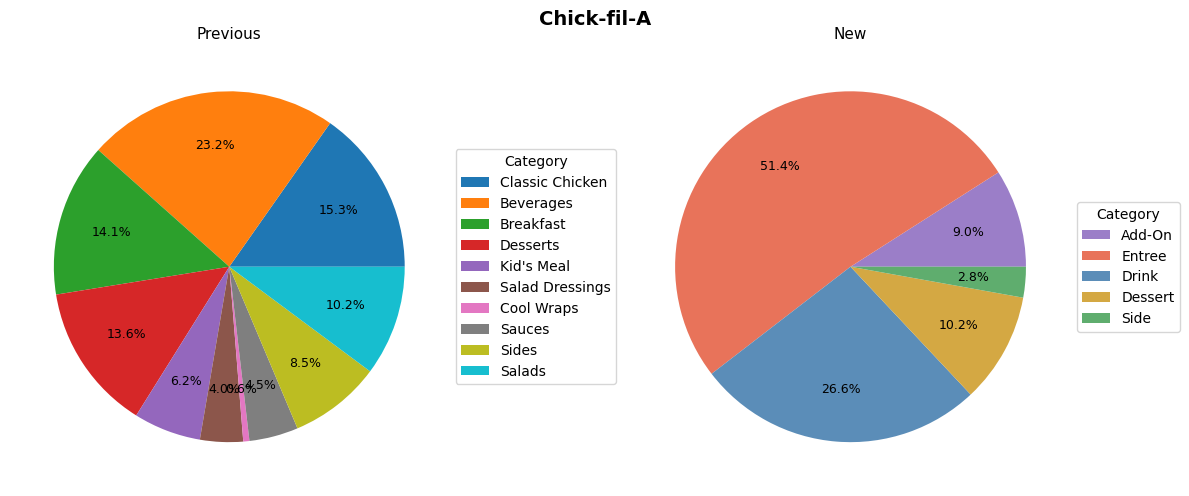

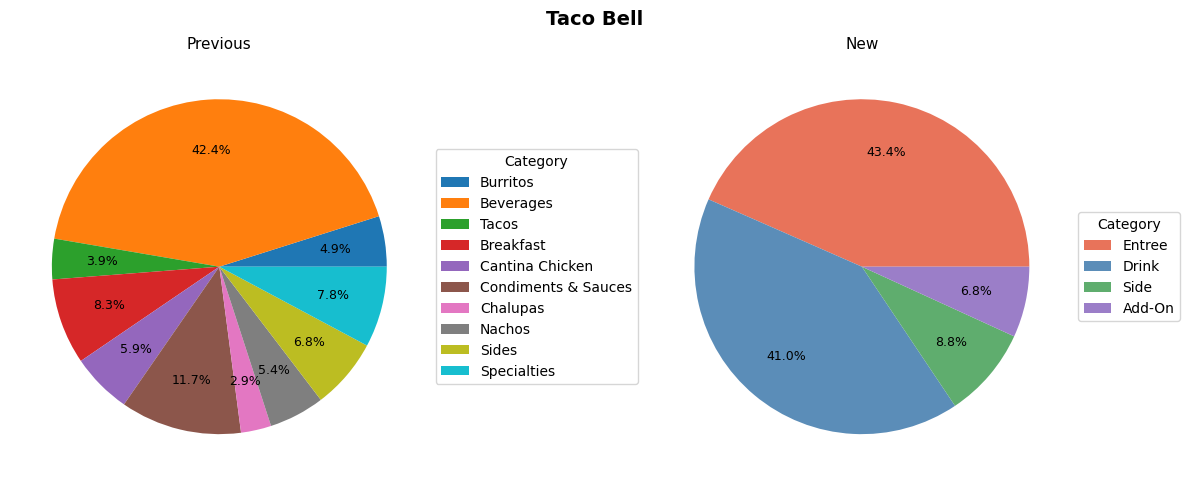

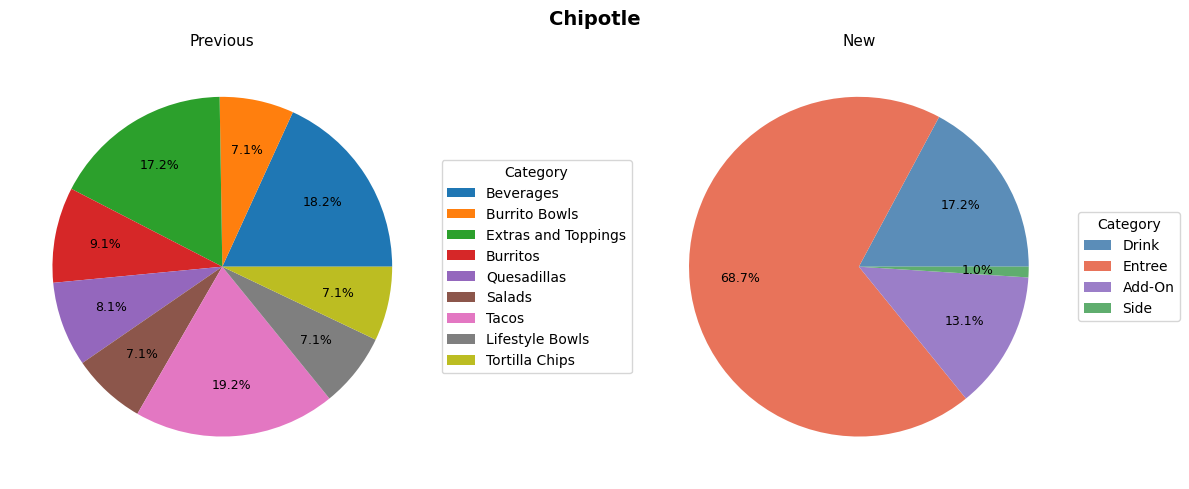

In [56]:
# Get items from Chick-fil-a, Taco Bell, and Chipotle
def get_selected_restaurants(items):
    cfa = []
    tb = []
    cp = []
    for item in items:
        if item["restaurant_name"] == "Chick-fil-A":
            cfa.append(item)
        elif item["restaurant_name"] == "Taco Bell":
            tb.append(item)
        elif item["restaurant_name"] == "Chipotle":
            cp.append(item)
    return cfa, tb, cp

# Get dict of category counts for each restaurant
def get_category_counts(items):
    category_counts = {}
    for item in items:
        cat = item["category"]
        if cat in category_counts:
            category_counts[cat] += 1
        else:
            category_counts[cat] = 1
    return category_counts

# Chick-fil-a, Taco Bell, Chiptole
prev_cfa, prev_tb, prev_cp = get_selected_restaurants(data)
new_cfa, new_tb, new_cp = get_selected_restaurants(good_cat)

prev_cfa_counts = get_category_counts(prev_cfa)
prev_tb_counts = get_category_counts(prev_tb)
prev_cp_counts = get_category_counts(prev_cp)
new_cfa_counts = get_category_counts(new_cfa)
new_tb_counts = get_category_counts(new_tb)
new_cp_counts = get_category_counts(new_cp)

CATEGORY_COLORS = {
    "Entree": "#E8735A",
    "Side": "#5FAD6E",
    "Drink": "#5B8DB8",
    "Add-On": "#9B7EC8",
    "Dessert": "#D4A843",
}

# Plotting the category distributions for each restaurant before and after categorization
def plot_category_distribution(prev_counts, new_counts, restaurant_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 12))
    fig.suptitle(restaurant_name, fontsize=14, fontweight='bold', y=.7)

    # Previous
    if prev_counts:
        wedges, _, _ = axes[0].pie(
            list(prev_counts.values()),
            labels=None,
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 9}
        )

        axes[0].legend(
            wedges,
            prev_counts.keys(),
            title="Category",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )
        axes[0].set_title("Previous", fontsize=11)
    else:
        axes[0].set_title(f"Previous - {restaurant_name} (no data)")

    # New
    if new_counts:
        colors = [CATEGORY_COLORS.get(cat, "gray") for cat in new_counts.keys()]
        wedges, _, _ = axes[1].pie(
            list(new_counts.values()),
            labels=None,
            autopct='%1.1f%%',
            pctdistance=0.7,
            textprops={'fontsize': 9},
            colors=colors
        )

        axes[1].legend(
            wedges,
            new_counts.keys(),
            title="Category",
            loc="center left",
            bbox_to_anchor=(1, 0.5)
        )
        axes[1].set_title("New", fontsize=11)
    else:
        axes[1].set_title(f"New - {restaurant_name} (no data)")

    plt.tight_layout()
    plt.show()

plot_category_distribution(prev_cfa_counts, new_cfa_counts, "Chick-fil-A")
plot_category_distribution(prev_tb_counts, new_tb_counts, "Taco Bell")
plot_category_distribution(prev_cp_counts, new_cp_counts, "Chipotle")

In [57]:
from collections import Counter

reason_counts = Counter(item["recategorize_reason"] for item in good_cat)
print("Recategorization reason counts:")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")

Recategorization reason counts:
category_match: 33208
calorie_upgrade: 1007
calorie_threshold: 58
override: 853


In [72]:
from collections import Counter

reason_counts = Counter(item["recategorize_reason"] for item in good_cat)
print("Recategorization reason counts (all items):")
for reason, count in reason_counts.items():
    print(f"{reason}: {count}")

Recategorization reason counts (all items):
category_match: 33208
calorie_upgrade: 1007
calorie_threshold: 58
override: 853


In [ ]:
# !pip install pandas

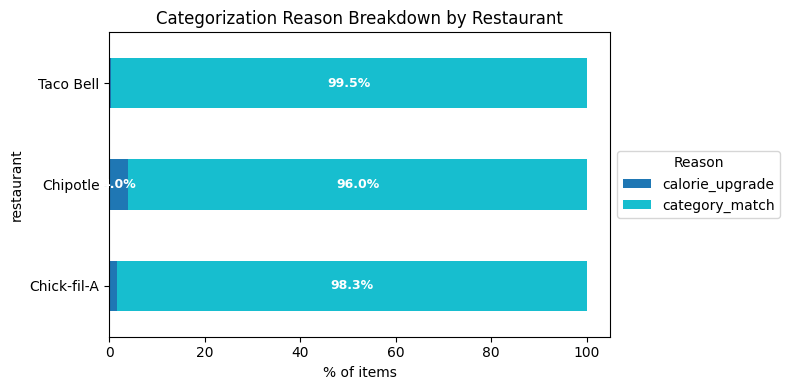

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_categorization_reasons(all_items):
    df = pd.DataFrame([
        {"restaurant": item["restaurant_name"], "recategorize_reason": item["recategorize_reason"]}
        for item in all_items
    ])

    counts = df.groupby(["restaurant", "recategorize_reason"]).size().unstack(fill_value=0)
    counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

    ax = counts_pct.plot(kind="barh", stacked=True, figsize=(8, 4), colormap="tab10")
    
    for bars in ax.containers:
        labels = [f"{v:.1f}%" if v >= 3 else "" for v in bars.datavalues]  # hide if too small
        ax.bar_label(bars, labels=labels, label_type="center", fontsize=9, color="white", fontweight="bold")

    ax.set_xlabel("% of items")
    ax.set_title("Categorization Reason Breakdown by Restaurant")
    ax.legend(title="Reason", bbox_to_anchor=(1, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()

# combine new_cfa, new_tb, new_cp for plotting
new_items = new_cfa + new_tb + new_cp

plot_categorization_reasons(new_items)